# Context-conditioned low-rank response (CCLR)

## tl;dr

94개 세포주의 lineage-aware outer 5-fold와 nested inner 4-fold에서 CCLR을
평가했다. CCLR의 B1 대비 RMSE gain은 `0.001367`, B4 대비 gain은
`-0.000348` (95% CI `-0.000584–-0.000105`)다. CCLR의 B4 대비 차이는 0을 가로질러 우위를 확정하지 못한다.
이 결과는 32,738-gene 반응을 training-fold의 공유 response component로 제한했을 때
직접 gene-level ridge보다 일반화가 좋아지는지를 검정한 것이다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/cclr_summary.json").read_text())
validation = json.loads((root / "results/logs/cclr_validation.json").read_text())
comparison = pd.read_csv(root / "results/tables/model_comparison_w6.csv")
hyperparameters = pd.read_csv(root / "results/tables/cclr_hyperparameters.csv")
component_summary = pd.read_csv(root / "results/tables/cclr_component_summary.csv")
loadings = pd.read_csv(root / "results/tables/cclr_component_top_loadings.csv")
artifact_manifest = pd.read_csv(root / "results/tables/cclr_model_artifacts.csv")
display(comparison.loc[comparison["model"].isin(["B1", "B4", "CCLR"]), [
    "model", "rmse_delta_mean", "pcc_delta_mean", "pcc_context_mean",
    "rmse_gain_vs_b1_mean", "rmse_gain_vs_b1_ci95_low", "rmse_gain_vs_b1_ci95_high",
    "rmse_gain_vs_b4_mean", "rmse_gain_vs_b4_ci95_low", "rmse_gain_vs_b4_ci95_high",
]])
display(hyperparameters)
assert summary["each_cell_line_predicted_once"]
assert summary["predictions_rows"] == 94
assert summary["outer_test_response_used_for_fit"] is False
assert summary["repeat_run_prediction_sha256_match"] is True
assert len(artifact_manifest) == 5
assert validation["status"] == "pass"


,model,rmse_delta_mean,pcc_delta_mean,pcc_context_mean,rmse_gain_vs_b1_mean,rmse_gain_vs_b1_ci95_low,rmse_gain_vs_b1_ci95_high,rmse_gain_vs_b4_mean,rmse_gain_vs_b4_ci95_low,rmse_gain_vs_b4_ci95_high
1,B1,0.323750,0.420086,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,B4,0.322035,0.428001,0.107666,0.001715,0.001168,0.002284,NaN,NaN,NaN
5,CCLR,0.322383,0.425501,0.096521,0.001367,0.000823,0.001933,-0.000348,-0.000584,-0.000105


,outer_fold,control_dimension,response_rank,alpha,selected_control_genes,response_variance_explained,parameter_count
0,0,30,20,100.0,5000,0.495239,688118
1,1,20,20,100.0,5000,0.503945,687918
2,2,10,20,100.0,5000,0.505694,687718
3,3,5,20,100.0,5000,0.491410,687618
4,4,20,20,100.0,5000,0.509896,687918


## Context & Methods

### Model

각 outer-training fold에서 response를 `Δ ≈ μ + Ws`로 PCA 압축한다. 같은
training control에서 상위 5,000 variable genes와 whitened PCA score `z`를 만들고,
ridge로 `z → s`를 학습한 뒤 `μ + Wŝ`로 32,738-gene response를 복원한다.

### Key Assumptions

- outer test 단위는 cell line이며 각 line은 정확히 한 번만 예측한다.
- control gene filter/PCA와 response PCA는 각 inner/outer training partition에서 다시 fit한다.
- control 차원, response rank, ridge alpha는 inner-CV macro RMSE로만 선택한다.
- response PCA component의 부호와 번호는 fold별로 임의이고 서로 직접 정렬되지 않는다.
- outer-test response는 모델 fit에 쓰지 않고, 예측 완료 후 metric과 component-score 평가에만 쓴다.
- sensitivity와 mutation은 predictor가 아니다.

## Results

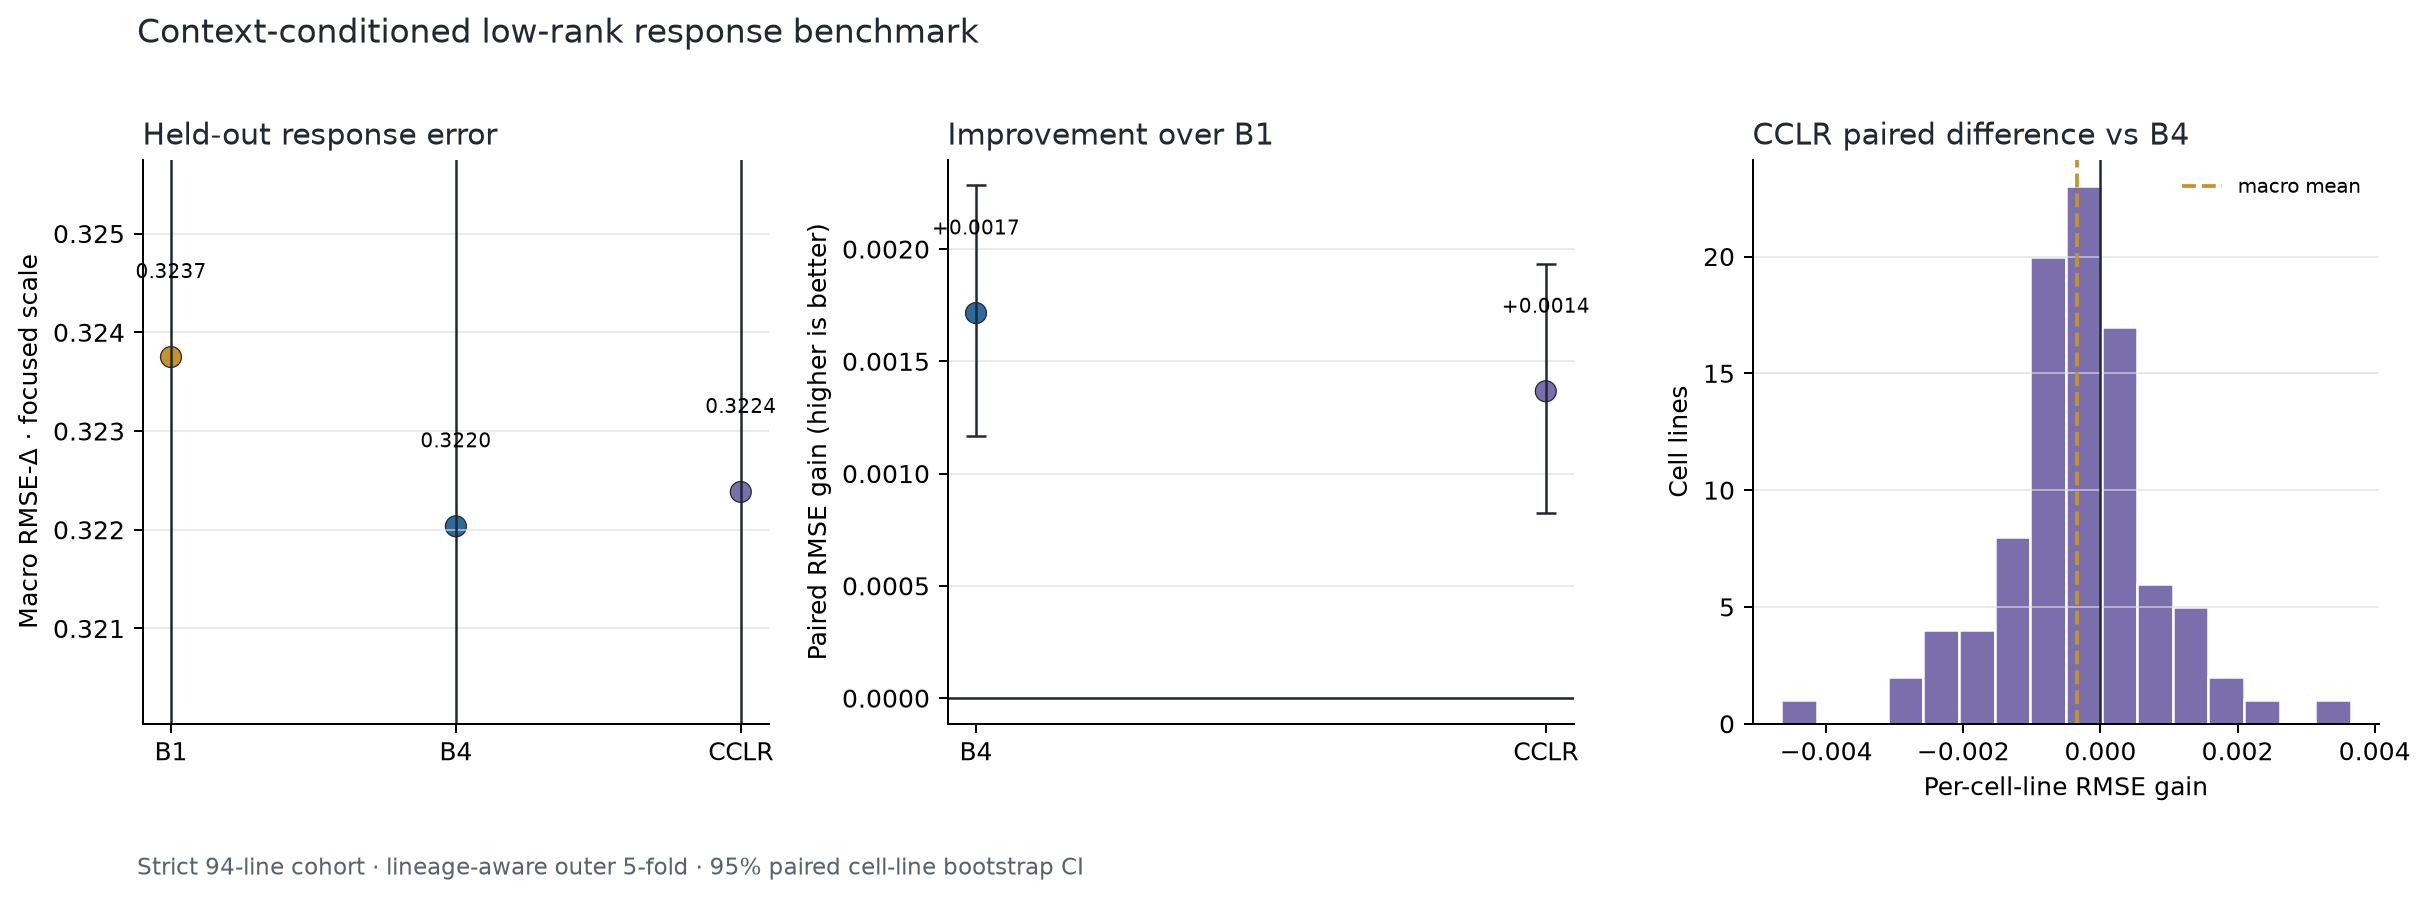

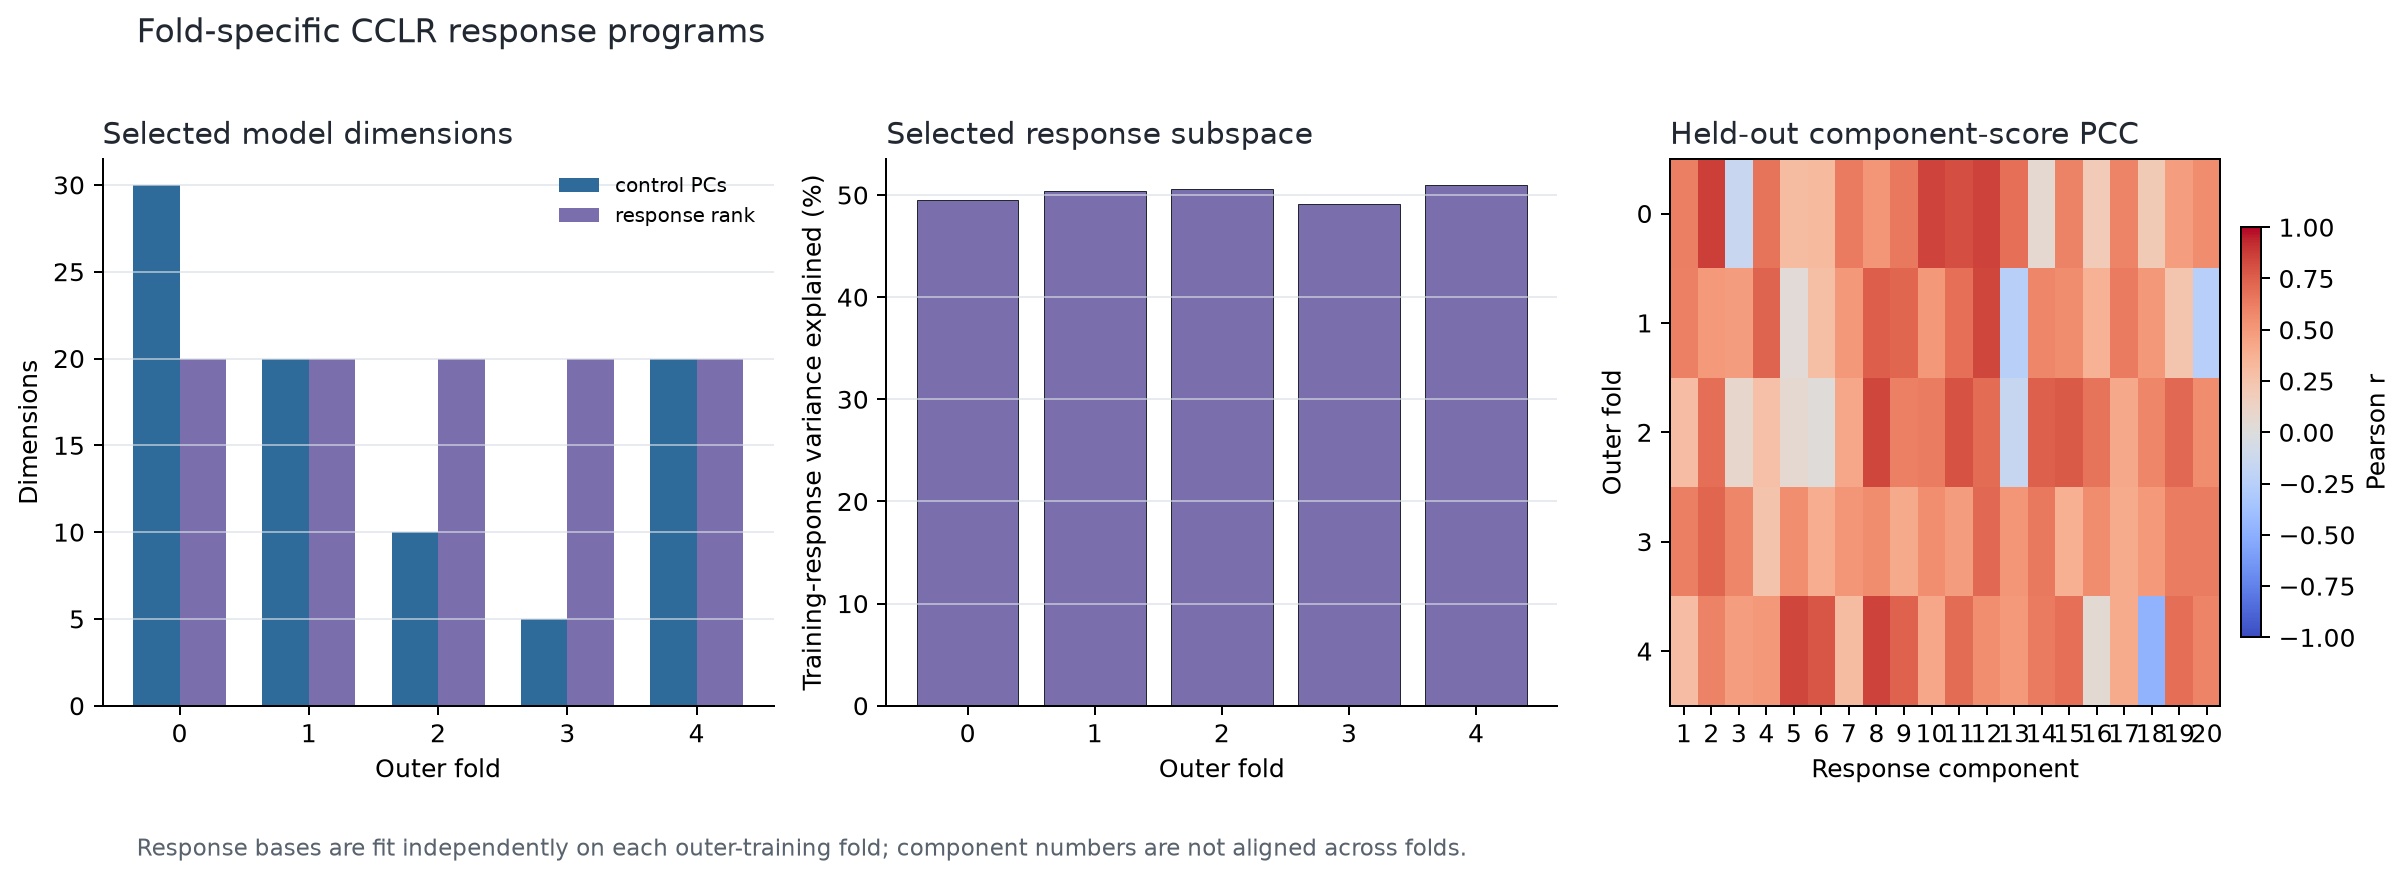

In [3]:
display(Image(filename=str(root / "results/figures/cclr_performance.png")))
display(Image(filename=str(root / "results/figures/cclr_components.png")))


### Component inspection

In [4]:
display(component_summary.head(20))
display(loadings.loc[
    loadings["loading_rank"].le(10),
    ["outer_fold", "component", "direction", "loading_rank", "gene_symbol", "loading"],
].head(40))


,outer_fold,component,n_test_lines,observed_vs_predicted_pcc,score_rmse,explained_variance_ratio
0,0,1,19,0.624660,7.108689,0.055537
1,0,2,19,0.861900,1.437765,0.039030
2,0,3,19,-0.144151,2.542983,0.035787
3,0,4,19,0.667338,4.702988,0.032143
4,0,5,19,0.303717,2.418575,0.029589
5,0,6,19,0.314521,3.452366,0.029335
6,0,7,19,0.638939,1.930846,0.023541
7,0,8,19,0.512824,1.320726,0.022782
8,0,9,19,0.643411,1.432200,0.022172
9,0,10,19,0.851396,1.445152,0.021498


,outer_fold,component,direction,loading_rank,gene_symbol,loading
0,0,1,negative,1,LY6D,-0.032152
1,0,1,negative,2,SEPP1,-0.029370
2,0,1,negative,3,RSAD2,-0.025758
3,0,1,negative,4,PDZK1IP1,-0.025307
4,0,1,negative,5,STEAP4,-0.024950
5,0,1,negative,6,PIK3IP1,-0.024933
6,0,1,negative,7,MSMB,-0.024857
7,0,1,negative,8,GBP2,-0.024258
8,0,1,negative,9,EXOC3L1,-0.023934
9,0,1,negative,10,TMEM161B,-0.023843


## Takeaways

- CCLR의 B1 대비 평균 RMSE gain은 `0.001367`다. 이는 baseline context가
  공유 저차원 반응 프로그램의 세기를 예측하는지에 대한 주 검정이다.
- CCLR의 B4 대비 paired gain 95% CI는 `-0.000584–-0.000105`다.
  CCLR의 B4 대비 차이는 0을 가로질러 우위를 확정하지 못한다.
- response rank와 control 차원이 fold마다 달라질 수 있어, component loading은
  fold별 해석 단위로 유지하며 component 번호를 전체 코호트의 고정 pathway로 보지 않는다.
- W6는 모델 비교를 완료하지만 pathway enrichment, rank/feature ablation, lineage·mutation
  확장은 W7의 별도 분석이다.